# **WEEK 4**

In [1]:
hotel <- read.csv("hotel_bookings.csv")

dim(hotel)

head(hotel)

str(hotel)

[1] 119390     32

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>
1,Resort Hotel,0,342,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,737,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
3,Resort Hotel,0,7,2015,July,27,1,0,1,1,⋯,No Deposit,NULL,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,13,2015,July,27,1,0,1,1,⋯,No Deposit,304,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03


'data.frame':	119390 obs. of  32 variables:
 $ hotel                         : chr  "Resort Hotel" "Resort Hotel" "Resort Hotel" "Resort Hotel" ...
 $ is_canceled                   : int  0 0 0 0 0 0 0 0 1 1 ...
 $ lead_time                     : int  342 737 7 13 14 14 0 9 85 75 ...
 $ arrival_date_year             : int  2015 2015 2015 2015 2015 2015 2015 2015 2015 2015 ...
 $ arrival_date_month            : chr  "July" "July" "July" "July" ...
 $ arrival_date_week_number      : int  27 27 27 27 27 27 27 27 27 27 ...
 $ arrival_date_day_of_month     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ stays_in_weekend_nights       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ stays_in_week_nights          : int  0 0 1 1 2 2 2 2 3 3 ...
 $ adults                        : int  2 2 1 1 2 2 2 2 2 2 ...
 $ children                      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ babies                        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ meal                          : chr  "BB" "BB" "BB" "BB" ...
 $ country                 

In [2]:
sum(is.na(hotel))

colSums(is.na(hotel))

sum(hotel$children == "NULL", na.rm = TRUE)

summary(hotel)

[1] 4

hotel                    is_canceled 
                             0                              0 
                     lead_time              arrival_date_year 
                             0                              0 
            arrival_date_month       arrival_date_week_number 
                             0                              0 
     arrival_date_day_of_month        stays_in_weekend_nights 
                             0                              0 
          stays_in_week_nights                         adults 
                             0                              0 
                      children                         babies 
                             4                              0 
                          meal                        country 
                             0                              0 
                market_segment           distribution_channel 
                             0                              0 
             is_repeated_guest         previous_cancellations 
                             0                              0 
previous_bookings_not_canceled             reserved_room_type 
                             0                              0 
            assigned_room_type                booking_changes 
                             0                              0 
                  deposit_type                          agent 
                             0                              0 
                       company           days_in_waiting_list 
                             0                              0 
                 customer_type                            adr 
                             0                              0 
   required_car_parking_spaces      total_of_special_requests 
                             0                              0 
            reservation_status        reservation_status_date 
                             0                              0

[1] 0

       hotel         is_canceled       lead_time   arrival_date_year
 Length   :119390   Min.   :0.0000   Min.   :  0   Min.   :2015     
 N.unique :     2   1st Qu.:0.0000   1st Qu.: 18   1st Qu.:2016     
 N.blank  :     0   Median :0.0000   Median : 69   Median :2016     
 Min.nchar:    10   Mean   :0.3704   Mean   :104   Mean   :2016     
 Max.nchar:    12   3rd Qu.:1.0000   3rd Qu.:160   3rd Qu.:2017     
                    Max.   :1.0000   Max.   :737   Max.   :2017     
                                                                    
 arrival_date_month arrival_date_week_number arrival_date_day_of_month
 Length   :119390   Min.   : 1.00            Min.   : 1.0             
 N.unique :    12   1st Qu.:16.00            1st Qu.: 8.0             
 N.blank  :     0   Median :28.00            Median :16.0             
 Min.nchar:     3   Mean   :27.17            Mean   :15.8             
 Max.nchar:     9   3rd Qu.:38.00            3rd Qu.:23.0             
                    Ma

# **Handle the 4 missing values**

In [3]:
hotel$children[is.na(hotel$children)] <- 0
sum(is.na(hotel))

[1] 0

In [4]:
table(hotel$is_canceled)
prop.table(table(hotel$is_canceled)) * 100


    0     1 
75166 44224 


       0        1 
62.95837 37.04163 

# **Cancellation visualization**

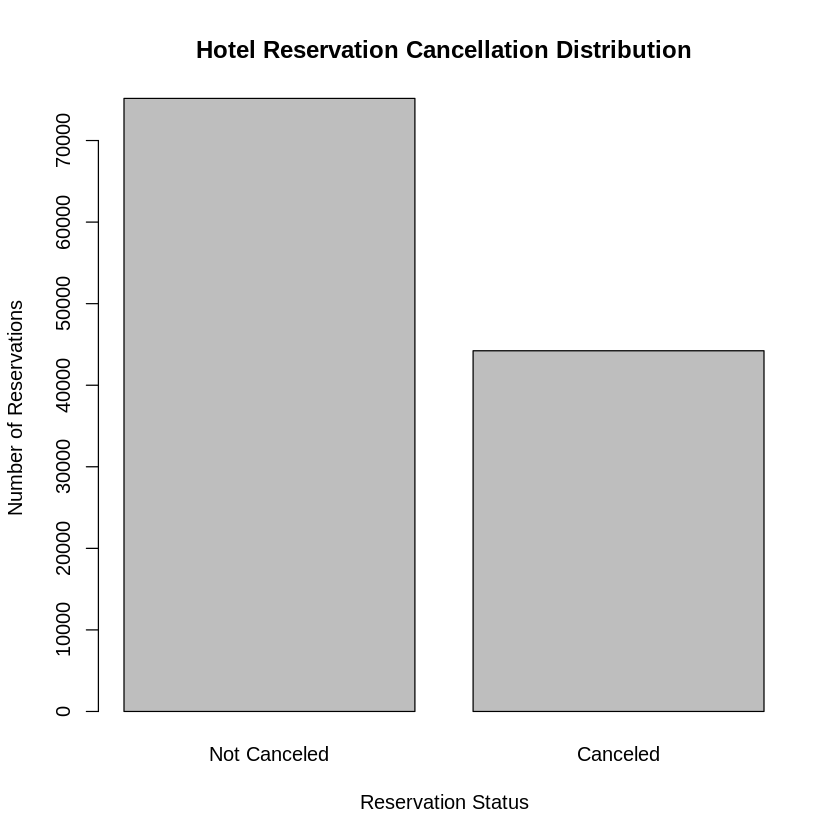

In [5]:
cancel_counts <- table(hotel$is_canceled)

barplot(
  cancel_counts,
  names.arg = c("Not Canceled", "Canceled"),
  main = "Hotel Reservation Cancellation Distribution",
  xlab = "Reservation Status",
  ylab = "Number of Reservations"
)

In [6]:
hotel_cancel <- table(hotel$hotel, hotel$is_canceled)
hotel_cancel_rate <- prop.table(hotel_cancel, margin = 1) * 100
hotel_cancel_rate

              
                      0        1
  City Hotel   58.27304 41.72696
  Resort Hotel 72.23665 27.76335

# **Create the visualization**

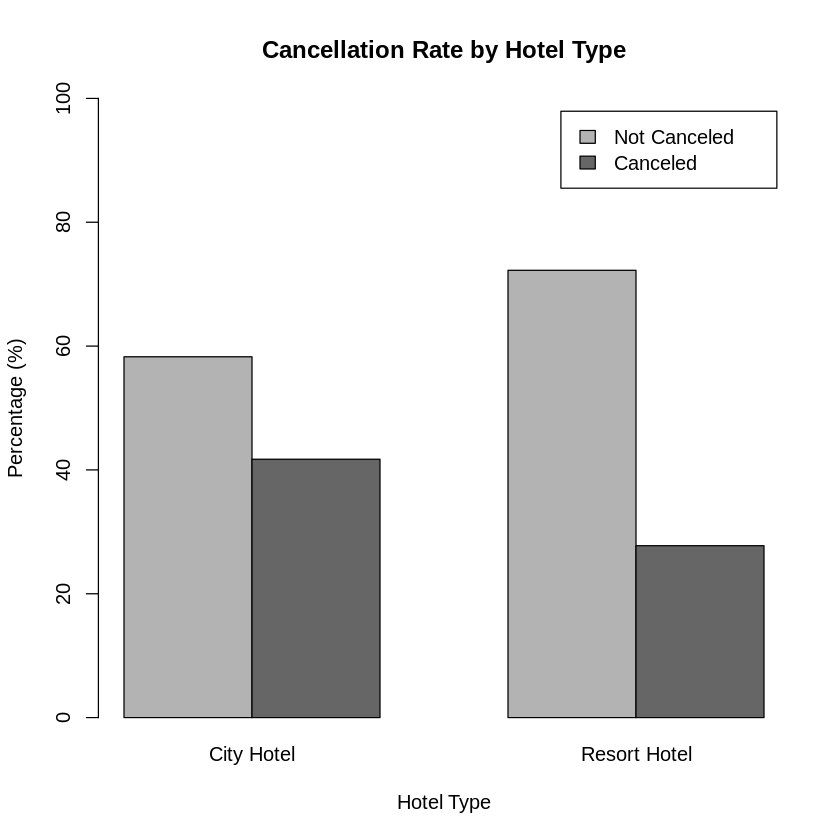

In [7]:
barplot(
  t(hotel_cancel_rate),
  beside = TRUE,
  names.arg = c("City Hotel", "Resort Hotel"),
  col = c("gray70", "gray40"),
  main = "Cancellation Rate by Hotel Type",
  xlab = "Hotel Type",
  ylab = "Percentage (%)",
  ylim = c(0, 100),
  legend.text = c("Not Canceled", "Canceled")
)

# **Analyze lead time**

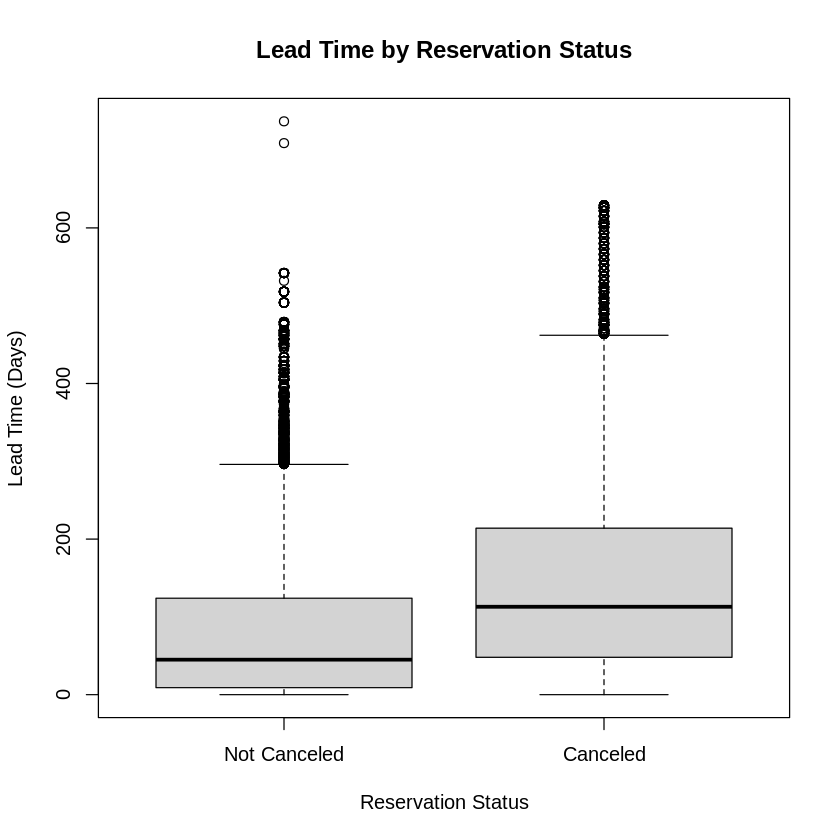

In [8]:
boxplot(
  lead_time ~ is_canceled,
  data = hotel,
  names = c("Not Canceled", "Canceled"),
  main = "Lead Time by Reservation Status",
  xlab = "Reservation Status",
  ylab = "Lead Time (Days)"
)

In [9]:
special_requests <- aggregate(
  total_of_special_requests ~ is_canceled,
  data = hotel,
  FUN = mean
)

special_requests

is_canceled,total_of_special_requests
<int>,<dbl>
0,0.7140595
1,0.3288260


# **Avg Special Requests**

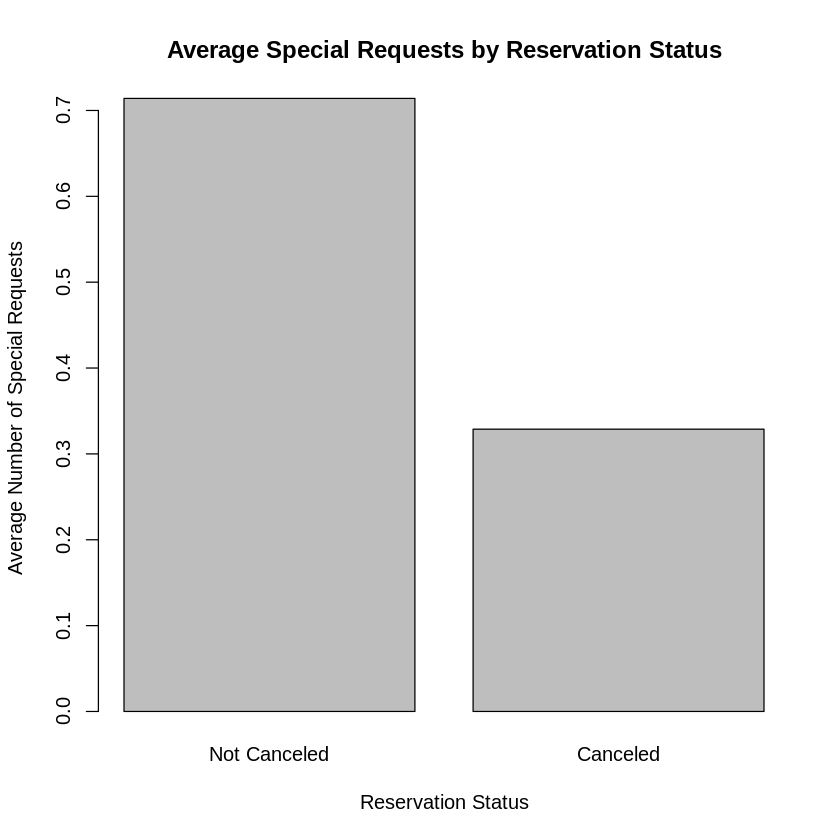

In [10]:
barplot(
  special_requests$total_of_special_requests,
  names.arg = c("Not Canceled", "Canceled"),
  main = "Average Special Requests by Reservation Status",
  xlab = "Reservation Status",
  ylab = "Average Number of Special Requests"
)

# **Final model performance visualization**

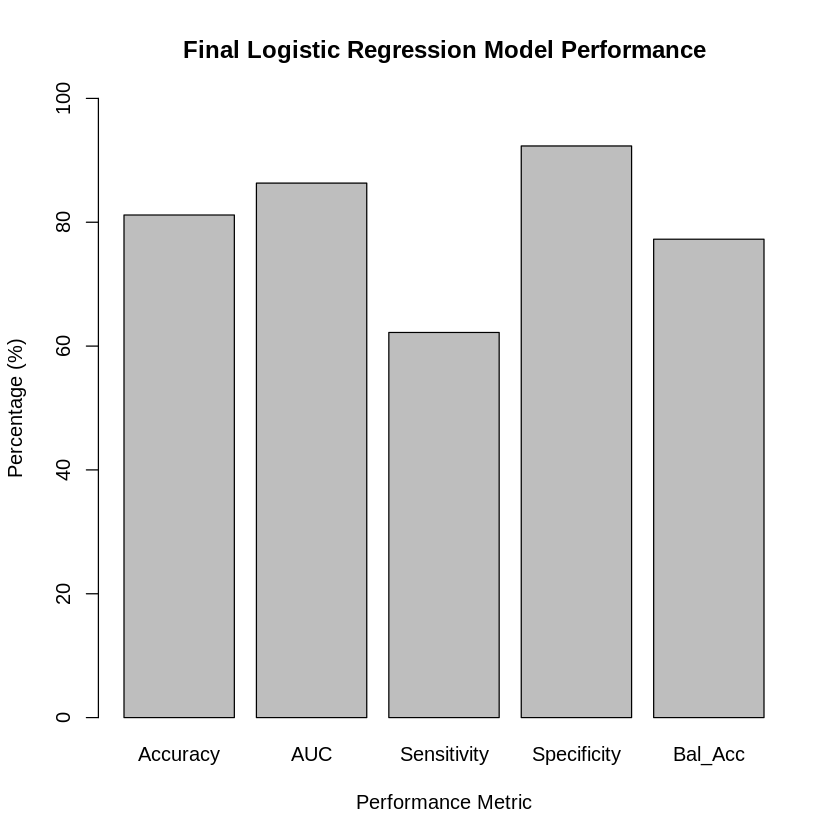

In [11]:
model_metrics <- c(
  Accuracy = 81.17,
  AUC = 86.32,
  Sensitivity = 62.20,
  Specificity = 92.32,
  Bal_Acc = 77.26
)

barplot(
  model_metrics,
  main = "Final Logistic Regression Model Performance",
  xlab = "Performance Metric",
  ylab = "Percentage (%)",
  ylim = c(0, 100)
)

# **Cancellation rate by deposit type**

In [12]:
deposit_cancel <- table(hotel$deposit_type, hotel$is_canceled)
deposit_cancel_rate <- prop.table(deposit_cancel, margin = 1) * 100
deposit_cancel_rate

            
                     0         1
  No Deposit 71.622978 28.377022
  Non Refund  0.637554 99.362446
  Refundable 77.777778 22.222222

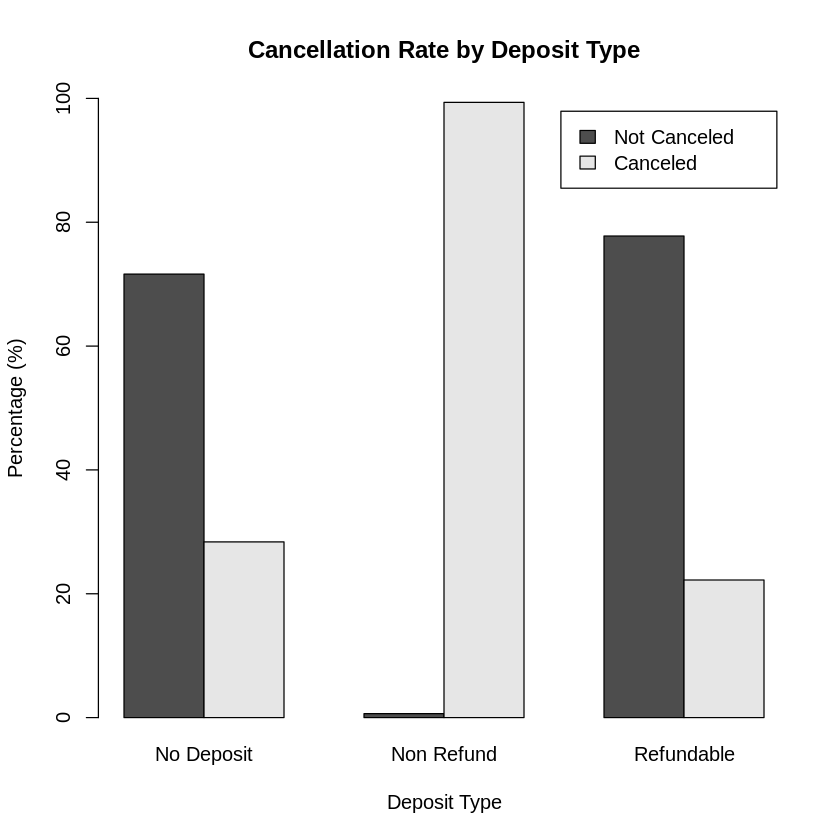

In [13]:
barplot(
  t(deposit_cancel_rate),
  beside = TRUE,
  names.arg = c("No Deposit", "Non Refund", "Refundable"),
  main = "Cancellation Rate by Deposit Type",
  xlab = "Deposit Type",
  ylab = "Percentage (%)",
  ylim = c(0, 100),
  legend.text = c("Not Canceled", "Canceled")
)

# **Previous cancellation history**

In [14]:
previous_cancel <- aggregate(
  previous_cancellations ~ is_canceled,
  data = hotel,
  FUN = mean
)
previous_cancel

is_canceled,previous_cancellations
<int>,<dbl>
0,0.01579171
1,0.20834841


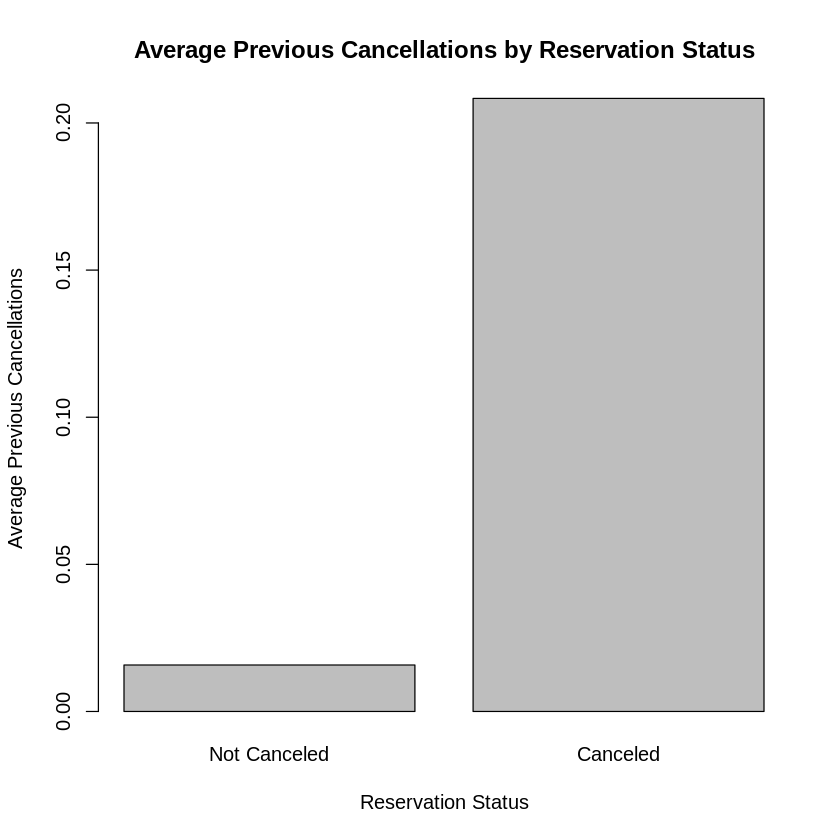

In [15]:
barplot(
  previous_cancel$previous_cancellations,
  names.arg = c("Not Canceled", "Canceled"),
  main = "Average Previous Cancellations by Reservation Status",
  xlab = "Reservation Status",
  ylab = "Average Previous Cancellations"
)

# **Create a consolidated findings table**

In [16]:
key_findings <- data.frame(
  Finding = c(
    "Overall cancellation rate",
    "City Hotel cancellation rate",
    "Resort Hotel cancellation rate",
    "Non Refund cancellation rate",
    "No Deposit cancellation rate",
    "Average lead time - Not Canceled",
    "Average lead time - Canceled",
    "Average previous cancellations - Not Canceled",
    "Average previous cancellations - Canceled"
  ),
  Result = c(
    "37.04%",
    "41.73%",
    "27.76%",
    "99.36%",
    "28.38%",
    "79.98 days",
    "144.85 days",
    "0.0158",
    "0.2083"
  )
)

key_findings

Finding,Result
<chr>,<chr>
Overall cancellation rate,37.04%
City Hotel cancellation rate,41.73%
Resort Hotel cancellation rate,27.76%
Non Refund cancellation rate,99.36%
No Deposit cancellation rate,28.38%
Average lead time - Not Canceled,79.98 days
Average lead time - Canceled,144.85 days
Average previous cancellations - Not Canceled,0.0158
Average previous cancellations - Canceled,0.2083


In [17]:
model_comparison <- data.frame(
  Metric = c(
    "Cross-validation AUC",
    "Test Accuracy",
    "Test Sensitivity",
    "Test Specificity",
    "Balanced Accuracy",
    "Kappa"
  ),
  Original_Model = c(
    0.8632,
    0.8117,
    0.6220,
    0.9232,
    0.7726,
    0.5745
  ),
  Optimized_Model = c(
    0.8171,
    0.7853,
    0.4945,
    0.9564,
    0.7254,
    0.4948
  )
)

model_comparison

Metric,Original_Model,Optimized_Model
<chr>,<dbl>,<dbl>
Cross-validation AUC,0.8632,0.8171
Test Accuracy,0.8117,0.7853
Test Sensitivity,0.6220,0.4945
Test Specificity,0.9232,0.9564
Balanced Accuracy,0.7726,0.7254
Kappa,0.5745,0.4948
